### Sliced Wasserstein Distance

Both point clouds are projected to 1D. Their 1D Wasserstein distance is computed. The result is averaged over n_projections.

I SHOULD DO A TEST MCMC WHERE I TRY TO MINIMIZE A MULTIVARIATE DISTRIBUTION AND SEE HOW THE SIZE OF THESE DISTRIBUTION CHANGES HOW ACCURATE THE WASSERSTEIN CAN DISTINGUISH BETWEEN TWO DISTRIBUTIONS

In [3]:
#> imports
import numpy as np
import scipy as sp
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

import ot

In [35]:
#> num dimensions
d = 2
size1 = 10
size2 = 1000

#> multivariate declarations
mu1 = np.zeros(shape=d)
mu2 = np.full(shape=d, fill_value=1)

cov1 = np.identity(n=d)
cov2 = np.identity(n=d)

#> print statements
print(f'> The means are {mu1}')
print(f'> The covariance matrix is :\n',cov1)

print(f'> The means are {mu2}')
print(f'> The covariance matrix is :\n',cov2)

#> drawing samples
ran_state = 2
samples1 = multivariate_normal.rvs(mean=mu1, cov=cov1, size=size1, random_state=ran_state)
samples2 = multivariate_normal.rvs(mean=mu2, cov=cov2, size=size2, random_state=ran_state)

#> comparing samples
n_projections = 1000 # num random projects (higher better)

# Calculate the distance
sw_distance = ot.sliced_wasserstein_distance(samples1,
                                             samples2,
                                             n_projections=n_projections)

print(f'The SW distance is {sw_distance}')

> The means are [0. 0.]
> The covariance matrix is :
 [[1. 0.]
 [0. 1.]]
> The means are [1 1]
> The covariance matrix is :
 [[1. 0.]
 [0. 1.]]
The SW distance is 1.2637558235828943


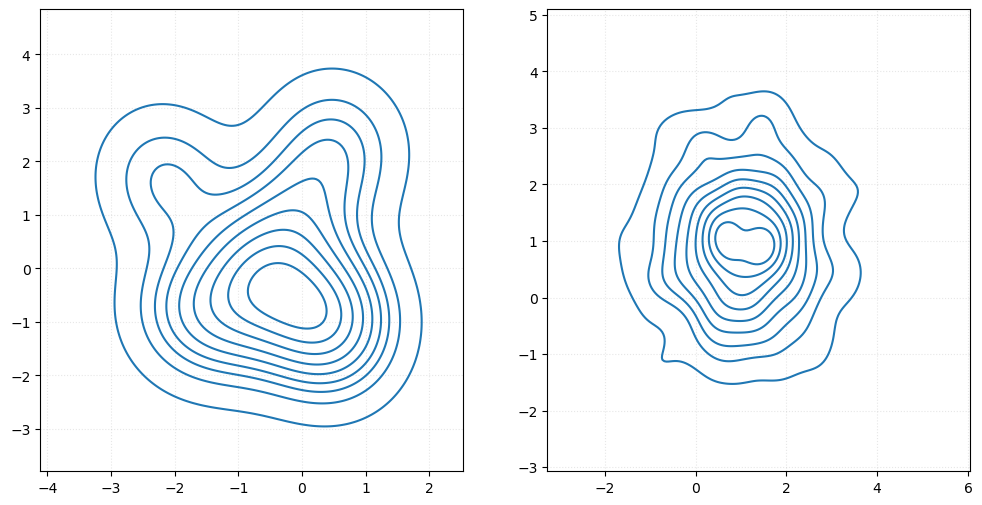

In [36]:
#> initializing plot
fig, axes = plt.subplots(1,2,figsize=(12,6))

for ax, samples in zip(axes.flat, [samples1, samples2]):
    ax.grid(ls=':', alpha=0.3)
    sns.kdeplot(x=samples[:,0], y=samples[:,1], ax=ax)
    
plt.show()

### Dimension Normalization Test

Q: Does the range of the parameter space affect the SW metric?
A: Yes!

In [34]:
#> drawing samples
ran_state = 2
samples1 = multivariate_normal.rvs(mean=mu1, cov=cov1, size=size1, random_state=ran_state)
samples2 = multivariate_normal.rvs(mean=mu2, cov=cov2, size=size2, random_state=ran_state)

factor = 1
samples1[:,1] *= factor
samples2[:,1] *= factor

# Calculate the distance
sw_distance = ot.sliced_wasserstein_distance(samples1,
                                             samples2,
                                             n_projections=n_projections)

print(f'The SW distance is {sw_distance}')

factor = 10
samples1[:,0] *= factor
samples2[:,0] *= factor

# Calculate the distance
sw_distance = ot.sliced_wasserstein_distance(samples1,
                                             samples2,
                                             n_projections=n_projections)

print(f'The partically rescaled SW distance is {sw_distance}')

factor = 10
samples1[:,1] *= factor
samples2[:,1] *= factor

# Calculate the distance
sw_distance = ot.sliced_wasserstein_distance(samples1,
                                             samples2,
                                             n_projections=n_projections)

print(f'The fully rescaled SW distance is {sw_distance}')

The SW distance is 1.2759916350718086
The partically rescaled SW distance is 10.582962674848392
The fully rescaled SW distance is 12.682610038092482
